### 1、单刚体模块角度分析、风浪联合下的作用。
### 2、研究结果详见RODM研究word文档。
### 3、在考虑系泊的情况下，计算出现的低频共振。

In [1]:
#import packages
import time
import numpy as np
import capytaine as cpt
import scipy
from capytaine.io.mesh_writers import write_STL
import matplotlib.pyplot as plt
from scipy.linalg import block_diag
from scipy.linalg import eigh
import vtk
import logging
import xarray as xr
from capytaine.io.xarray import merge_complex_values
from capytaine.post_pro import rao
logging.basicConfig(level=logging.INFO, format='%(levelname)-8s: %(message)s')
# user defined functions
import DM_ShowNodes as DMshow
import DM_Reading as dm_r
import DM_Assemble as DM_A
import SEREP as SEREP
import DM_Method as DM_M
# 引入风载荷
import DM_Windload as DM_Wind

### 对比系泊问题

In [2]:
dataset = merge_complex_values(xr.open_dataset("E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoga\DM1_direaction0_full100_yoga.nc"))
wave_direction = 0
stiffness = 1e6
# Calculate the rao and add it to the dataset
local_stiffness_matrix = np.zeros((6, 6))
local_stiffness_matrix[0, 0] = stiffness  # x方向刚度
local_stiffness_matrix[1, 1] = stiffness  # y方向刚度

In [3]:
dataset['rao_mooring'] = rao(dataset, wave_direction=wave_direction, dissipation=None, stiffness=local_stiffness_matrix)
dataset['rao'] = rao(dataset, wave_direction=wave_direction, dissipation=None, stiffness=None)

INFO    : Compute RAO.
INFO    : Compute RAO.


In [15]:
mass = (dataset["inertia_matrix"].values[0,0] + dataset["added_mass"][10].values[0,0])

In [17]:
k = 4*1e5
print(np.sqrt(k/mass))

0.20708434064419926


In [10]:
dataset.omega.values[10]

0.20999999999999996

In [4]:
Hs = 2.75          #Hs = np.array([1., 2., 3., 4., 5., 6.]) #Tp = np.array([4.57, 6.46, 7.91, 9.13, 10.21, 11.18])
Tp = 7.78
omega = dataset.omega.values
import wave_spectrum as ws
S_wave = ws.jonswap(Hs, Tp, omega)
S_wave_expanded = np.tile(S_wave[:, np.newaxis], (1, 6))
# plt.plot(S_wave)

In [ ]:
plt.plot(S_wave_expanded[:,1])

In [5]:
dataset['rao_mooring_spectrum'] = dataset['rao_mooring']**2 * S_wave_expanded
dataset['rao_spectrum'] = dataset['rao']**2 * S_wave_expanded

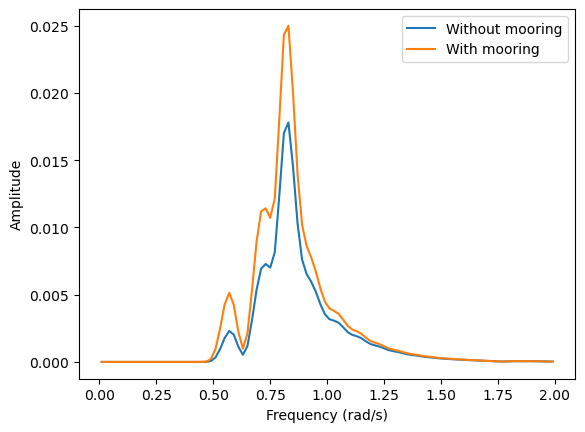

In [6]:
i = 0
plt.plot(dataset.omega, np.abs(dataset.rao_spectrum[:,i::6]))
plt.plot(dataset.omega, np.abs(dataset.rao_mooring_spectrum[:,i::6]))
plt.legend(['Without mooring', 'With mooring'])
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Amplitude')
plt.show()

In [7]:
import numpy as np

def compute_wind_load_and_damping(wind_speed, wind_direction, distance, df):
    windload_cd_file = f"E:\\phd\\Code\\DM-FEM2D\\winddata\\Ti0.1_cd_degree{wind_direction}.txt"
    windload_cl_file = f"E:\\phd\\Code\\DM-FEM2D\\winddata\\Ti0.1_cl_degree{wind_direction}.txt"

    windload_cd = DM_Wind.WindLoad(U10=wind_speed, z=2, total_rows=31, total_cols=151, file_path=windload_cd_file, wind_direction=wind_direction)
    windload_cl = DM_Wind.WindLoad(U10=wind_speed, z=2, total_rows=31, total_cols=151, file_path=windload_cl_file, wind_direction=wind_direction)
    windload_cd_damping = DM_Wind.WindLoad(U10=wind_speed, z=2, total_rows=13, total_cols=61, file_path=windload_cd_file, wind_direction=wind_direction)
    windload_cl_damping = DM_Wind.WindLoad(U10=wind_speed, z=2, total_rows=13, total_cols=61, file_path=windload_cl_file, wind_direction=wind_direction)

    # Calculate wind damping effects
    Wind_Damping = (windload_cd_damping.compute_wind_damping(dof=0) + 
                    windload_cl_damping.compute_wind_damping(dof=2) + 
                    windload_cd_damping.compute_wind_damping(dof=4)) * 5.9  # Conversion coefficient

    C11 = np.sum(np.diag(Wind_Damping[0::6, 0::6]))
    C33 = np.sum(np.diag(Wind_Damping[2::6, 2::6]))
    C55 = np.sum(np.diag(Wind_Damping[4::6, 4::6]))

    dissipation = np.zeros((6, 6))
    dissipation[0, 0] = C11
    dissipation[2, 2] = C33
    dissipation[4, 4] = C55

    cd_sums, cd_submodules = windload_cd.wind_coefficient_lumped()
    cl_sums, cl_submodules = windload_cl.wind_coefficient_lumped()

    # Define target frequency range
    frequencies = np.arange(0.01, 2.00, df)
    wind_load_matrix = np.zeros((len(frequencies), 1, 6))

    for i, freq in enumerate(frequencies):
        wind_load = windload_cd.wind_force_lumped(target_frequency=freq, distance=distance,
                                                  cd_sums=cd_sums, cl_sums=cl_sums,
                                                  cl_submodules=cl_submodules)
        wind_load_matrix[i, 0, 0] = np.sum(np.abs(wind_load[:, 0::5]))
        wind_load_matrix[i, 0, 2] = np.sum(np.abs(wind_load[:, 2::5]))
        wind_load_matrix[i, 0, 4] = np.sum(np.abs(wind_load[:, 4::5]))

    return dissipation, wind_load_matrix

# Call the function with provided parameters
damping_matrix, load_matrix = compute_wind_load_and_damping(wind_speed=50, wind_direction=0, distance=30, df=0.02)
damping_expanded = np.tile(damping_matrix, (100, 1, 1))

In [8]:
from capytaine.post_pro.impedance import rao_transfer_function
# ASSEMBLE MATRICES
omega = dataset.coords['omega']
H = (-omega**2*(dataset['inertia_matrix'] + dataset['added_mass'])
         - 1j*omega*dataset['radiation_damping']
         + dataset['hydrostatic_stiffness'])
omega_reshaped = omega.values[:, np.newaxis, np.newaxis]
H = H - 1j * omega_reshaped * damping_expanded # 考虑风的耗散
H = H + local_stiffness_matrix

H = H.transpose('omega', 'radiating_dof', 'influenced_dof')
excitation = load_matrix.reshape(100,6) # 风的激励力
X = np.linalg.solve(H, excitation)
dataset["rao_spectrum_wind"] = xr.DataArray(X, coords=[omega, dataset.coords['influenced_dof']], dims=['omega', 'influenced_dof'])
# omega = dataset.coords['omega']

if 'excitation_force' not in dataset:
    dataset['excitation_force'] = dataset['Froude_Krylov_force'] + dataset['diffraction_force']
excitation_wave = dataset['excitation_force'].sel(wave_direction=wave_direction)
excitation_wave = excitation_wave.transpose('omega', 'influenced_dof')
X_wave = np.linalg.solve(H, excitation_wave)
dataset["rao_wave_considerwinddamping"] = xr.DataArray(X_wave, coords=[omega, dataset.coords['influenced_dof']], dims=['omega', 'influenced_dof'])
dataset["rao_wave_spectrum"] = dataset["rao_wave_considerwinddamping"]**2 * S_wave_expanded

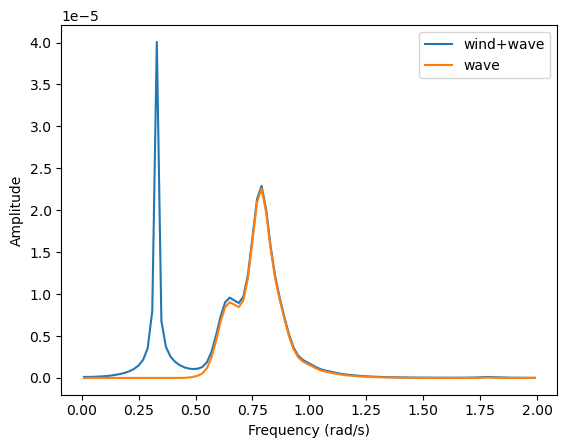

In [13]:
i = 4
plt.plot(dataset.omega, np.abs(dataset.rao_wave_spectrum[:,i::6]) + np.abs(dataset.rao_spectrum_wind[:,i::6]))
plt.plot(dataset.omega,np.abs(dataset.rao_spectrum[:,i::6]))
plt.legend(['wind+wave', 'wave'])
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Amplitude')
plt.show()

In [ ]:
dataset['radiation_damping'].shape

In [ ]:
dataset['rao'] = xr.DataArray(X, coords=[omega, dataset.coords['radiating_dof']], dims=['omega', 'radiating_dof'])

In [ ]:
damping_matrix.shape

In [ ]:
i = 0
plt.plot(dataset.omega, np.abs(dataset.rao[:,i::6]))
plt.plot(dataset.omega, np.abs(dataset.rao_mooring[:,i::6]))
plt.legend(['Without mooring', 'With mooring'])
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Amplitude')
plt.show()

In [ ]:
plt.plot(dataset.omega, np.abs(dataset.rao_mooring[:,i::6]))

In [ ]:
def create_mooring_stiffness_matrix(stiffness_value):
    # 创建一个总的刚度矩阵，维度为 (total_nodes*6, total_nodes*6)
    total_nodes = 793
    total_dof = total_nodes * 5
    global_stiffness_matrix = np.zeros((total_dof, total_dof))
    
    # 确定四个角点的节点编号
    node1 = 1
    node2 = 61
    node3 = 733
    node4 = 793
    
    # 四个系泊点的节点列表
    mooring_nodes = [node1, node2, node3, node4]
    
    # 定义6x6的局部刚度矩阵
    local_stiffness_matrix = np.zeros((5, 5))
    local_stiffness_matrix[0, 0] = stiffness_value  # x方向刚度
    local_stiffness_matrix[1, 1] = stiffness_value  # y方向刚度
    
    # 将局部刚度矩阵插入到总的刚度矩阵中
    for node in mooring_nodes:
        start_index = (node - 1) * 5
        for i in range(5):  # 只处理前5个自由度
            for j in range(5):
                global_stiffness_matrix[start_index + i, start_index + j] = local_stiffness_matrix[i, j]
    
    return global_stiffness_matrix

In [ ]:
omega = dataset.omega.values
omega_number = np.arange(0,199,1)
# 引入波浪谱
import wave_spectrum as ws
S_wave = ws.jonswap(Hs, Tp, omega)

# 引入风载荷
import DM_Windload as DM_Wind

windload_cd_file = f"E:\phd\Code\DM-FEM2D\winddata\Ti0.1_cd_degree{wind_direction}.txt"
windload_cl_file = f"E:\phd\Code\DM-FEM2D\winddata\Ti0.1_cl_degree{wind_direction}.txt"
windload_cd = DM_Wind.WindLoad(U10=wind_speed, z=2, total_rows=31, total_cols=151, file_path=windload_cd_file,wind_direction = wind_direction)
windload_cl = DM_Wind.WindLoad(U10=wind_speed, z=2, total_rows=31, total_cols=151, file_path=windload_cl_file,wind_direction = wind_direction)
windload_cd_damping = DM_Wind.WindLoad(U10=wind_speed, z=2, total_rows=13, total_cols=61, file_path=windload_cd_file,wind_direction = wind_direction)
windload_cl_damping = DM_Wind.WindLoad(U10=wind_speed, z=2, total_rows=13, total_cols=61, file_path=windload_cl_file,wind_direction = wind_direction)
# 计算风产生的阻尼效应feng
Wind_Damping = (windload_cd_damping.compute_wind_damping(dof=0) + 
                windload_cl_damping.compute_wind_damping(dof=2) + 
                windload_cd_damping.compute_wind_damping(dof=4))*5.9 # 5.9是转化系数多节点到少节点
Wind_Damping = SEREP.reduce_dofs(Wind_Damping,num_nodes,[5])
# 形成集中风载荷
cd_sums,cd_submodules = windload_cd.wind_coefficient_lumped()
cl_sums,cl_submodules = windload_cl.wind_coefficient_lumped()
Area = 5*5
nodes_per_row = 61

# read mass and stiffness matrix
M = dm_r.get_stiffness_matrix(file_m)
k = dm_r.get_stiffness_matrix(file_k)

# reduce dofs
M_consistant= SEREP.reduce_dofs(M, num_nodes, [5])

if use_mooring:
    k = SEREP.reduce_dofs(k, num_nodes, [5]) + create_mooring_stiffness_matrix(stiffness_value = 1e8)
else:
    k = SEREP.reduce_dofs(k, num_nodes, [5])

# transform mass matrix, beta=0 is consistant mass matrix
M = SEREP.transform_mass_matrix(M_consistant,beta=0)
# obtaine master dofs and slave dofs
MasterDofs, SlaveDofs = SEREP.separate_dofs(num_nodes, master_nodes)

# reduce matrix use SEREP
MR,KR,T = SEREP.SEREP(k, M, SlaveDofs, master_nodes)
# node displacement
displacement = []
F_wave = []
mass_full = []
damping_full = []
stiffness_full = []
F_winds = []  
for i in omega_number:
    # print("计算进展：",i/39)
    # wind load    omega
    wind_load = windload_cd.wind_force_lumped(target_frequency=omega[i],distance=distance,cd_sums=cd_sums,cl_sums=cl_sums,cl_submodules=cl_submodules)
    # read hydrodynamic data
    added_mass = dataset['added_mass'][i].values
    radiation_damping = dataset['radiation_damping'][i].values
    # inertia_matrix = dataset['inertia_matrix'].values
    # hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
    F_w = dataset['Froude_Krylov_force'][i].values + dataset['diffraction_force'][i].values
    # consider wave spectrum
    F_w = F_w * np.sqrt(S_wave[i]*df)
    # REDUCE THE MATRICES
    added_mass = SEREP.reduce_dofs(added_mass,master_nodes_length,[5])
    radiation_damping = SEREP.reduce_dofs(radiation_damping,master_nodes_length,[5])
    # hyrostatic stiffness or fem spring stiffness
    # 1. choice hydrostatic stiffness
    if use_hydrostatic:
        hydrostatic_stiffness = SEREP.reduce_dofs(dataset['hydrostatic_stiffness'].values, 10, [5])
        stiffness = hydrostatic_stiffness + KR
    else:
        total_nodes = 793
        nodes_per_row = 61
        area = 5 * 5
        k_fem = SEREP.get_fem_spring_stiffness(total_nodes, nodes_per_row, area)
        k_fem = SEREP.reduce_dofs(k_fem, num_nodes, [5])
        stiffness = T.T@k_fem@T + KR

    F_w = SEREP.reduce_force_matrix_dofs(F_w, master_nodes_length, 5).reshape(1,5*master_nodes_length)

    # Generate the system matrices
    mass = added_mass + MR
    damping = radiation_damping + T.T@Wind_Damping@T * F_wind_damping
    total_force = F_w * F_wave_coifficient + wind_load * F_wind_coifficient
    # total_force = np.ones((1,5*master_nodes_length))
    # F_w = reverse_load_matrix(F_w, num_dofs=5)
    # Solve in frequency domain
    master_displacement = DM_A.solve_frequency_domain(mass, damping, stiffness, total_force, omega[i])
    # Restore global displacement under disorder masterdofs and slavedofs
    global_displacement_disorder = T @ master_displacement
    # Reorder global displacement under order
    global_displacement = SEREP.reorder_displacement_matrix(global_displacement_disorder, MasterDofs, SlaveDofs)
    # find the error, which is the difference between the master_displacement and the global_displacement of master positions,
    # so we use master_displacement to replace the global_displacement of master positions.
    global_displacement_replace = DM_M.replace_master_with_global(master_displacement, global_displacement, master_nodes)

    # 保存数据
    mid = global_displacement_replace[interest_dof::5,:]
    displacement.append(mid)
    F_wave.append(F_w)
    mass_full.append(mass)
    damping_full.append(damping)
    stiffness_full.append(stiffness)
    F_winds.append(wind_load)


In [ ]:
np.diag(k[0:100])

In [ ]:
f = np.arange(0.01, 2.0, 0.01)
plt.plot(f, windload_cd.api_spectrum())

In [ ]:
1.225*2*2*5*np.sqrt(120*0.01*2)

In [ ]:
plt.plot(cd_sums)
plt.plot(cl_sums)

### 以RAO形式来检查谱

In [ ]:
displacement = np.array(displacement).reshape(199,13,61)
np.save('displacement_heave_waveandwind.npy',displacement)

In [ ]:
displacement_wave = np.load('displacement_heave_wave.npy')
displacement_wind = np.load('displacement_heave_waveandwind.npy')

In [ ]:
plt.plot(abs(displacement_wave[:,7,60]))
plt.plot(abs(displacement_wind[:,7,60]))
plt.legend(['wave','wave and wind'])
plt.show()

### 检查单一频率下的运动结果

In [ ]:
displacement = np.array(displacement).reshape(199,13,61)
plt.imshow(abs(displacement[100,:,:]))
plt.colorbar()

### 计算整体的平均运动相应屁，对所有节点取平均值再开方除以频率间隔

In [ ]:
mean_displacement = np.mean(abs(displacement.reshape(199,793)),axis=1)
# mean_displacement_top = np.mean(abs(displacement.reshape(199,793)[:,0:5]),axis=1)

plt.plot(omega,(mean_displacement**2/0.01))
# plt.plot(omega,(mean_displacement_top**2/0.01))

### log 图

In [ ]:
mean_displacement = np.mean(abs(displacement.reshape(199,793)), axis=1)
# first_displacement = np.mean(np.abs(wind_displacement[:,0:5]), axis=1)
plt.plot(omega,(mean_displacement**2/0.01))
# plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", ls="--")

### 先得到每个节点上的运动响应谱，绘制均方根云图

In [ ]:
# 先算运动响应谱
S_spectrum = np.abs(displacement.reshape(199,793))**2/0.01
# 根据公式乘以dw
wind_displacement_df = S_spectrum*0.01
# 求每一列的和
wind_displacement_sum = np.sum(wind_displacement_df, axis=0)
wind_displacement_root_mean_square = wind_displacement_sum.reshape(13, 61)
plt.imshow(np.sqrt(wind_displacement_root_mean_square))
plt.colorbar()

In [ ]:
# 检查风载荷的力和相位
n = 100
F_winds = np.array(wind_load).reshape(199,50)
plt.plot(abs(F_winds[n,0::5]))
plt.plot(abs(F_winds[n,2::5]))
plt.plot(abs(F_winds[n,4::5]))
plt.legend(['Fx','Fy','Mz'])

In [ ]:
plt.plot(np.angle(F_winds[n,0::5]))
plt.plot(np.angle(F_winds[n,2::5]))
plt.plot(np.angle(F_winds[n,4::5]))
plt.legend(['Fx','Fy','Mz'])

In [ ]:
wwwww = hydrostatic_stiffness[0:5,0:5]
plt.imshow(wwwww)
plt.colorbar()

In [ ]:
plt.plot(omega,np.mean(abs(displacement.reshape(199,793)),axis=1))
import DM_Verify as DM_V
dataset1 = DM_V.verify_hydrodynamic_data("E:\phd\Code\DM-FEM2D\HydrodynamicData\wind_stduy\BM10_direaction0_full200.nc", omega=124)
heave = abs(dataset1["rao"].values[:,2::6]).sum(axis=1)/10
plt.plot(omega,heave)

In [ ]:
mean_displacement[125]

In [ ]:
Damping =  dataset['added_mass'][100:150].values
i = 2
j = 4
plt.plot(omega[100:150],Damping[:,i,j])

In [ ]:
dataset

In [ ]:
dataset['radiation_damping'][100:150].values.shape

In [ ]:
plt.imshow(dataset["radiation_damping"][125].values)#,vmin=-1e8, vmax=3e8 
plt.colorbar()

In [ ]:
30*60*0.1*1025

In [ ]:
import os
import re

def sort_files(file):
    # This function extracts the numerical values for Hs and Wind from filenames
    # and returns a tuple (Hs, Wind) for sorting purposes.
    # Example filename: 'displacement_Hs1.0_Wind5.npy'
    hs = float(re.search(r'Hs(\d+\.\d+)_', file).group(1))
    wind = int(re.search(r'Wind(\d+)', file).group(1))
    return (hs, wind)

# Directory where the npy files are stored
results_directory = 'E:\\phd\\Code\\DM-FEM2D\\FEM_Reduce\\Results'

# List all npy files
files = [os.path.join(results_directory, f) for f in os.listdir(results_directory) if f.endswith('.npy')]

# Sort files based on the custom key function that parses the wave height and wind speed
files = sorted(files, key=sort_files)

# Now files are sorted first by Hs and then by wind speed within each Hs group
# print("Sorted files:")
# for file in files:
#     print(file)
import numpy as np

all_data = []
for file in files:
    # Load each file and append its contents to the list
    data = np.load(file)
    all_data.append(data)
    # print(f"Loaded {file}")

# Continue with data analysis...

In [ ]:
mean_displacement = np.mean(np.abs(all_data[11]), axis=1)
S_spectrum = mean_displacement**2 / 0.01
plt.plot(S_spectrum)

In [ ]:
plt.imshow(all_data[0][100,:].reshape(21,101))
plt.colorbar()

In [ ]:
wind_displacement_df = np.abs(all_data[11].reshape(199,2121))*0.01 # 2121 
# 求每一列的和
wind_displacement_sum = np.sum(wind_displacement_df, axis=0)
wind_displacement_root_mean_square = wind_displacement_sum.reshape(21, 101)  # 13 61
plt.imshow(np.sqrt(wind_displacement_root_mean_square)) 
plt.colorbar()

In [ ]:
import numpy as np

# Lists to store results
mean_displacements = []
spectral_densities = []
wind_displacement_sums = []

for data in all_data:
    # Calculate the mean displacement for each frequency (assumes data is structured with frequencies as rows)
    mean_displacement = np.mean(np.abs(data), axis=1)
    mean_displacements.append(mean_displacement)
    
    # Calculate the spectral power density
    S_spectrum = mean_displacement**2 / 0.01
    spectral_densities.append(S_spectrum)
    
    # Sum the spectral power densities and multiply by 0.01 (possibly to adjust the scale or units)
    wind_displacement_sum = np.sum(S_spectrum * 0.01)
    wind_displacement_sums.append(wind_displacement_sum)

# Optionally, convert lists to numpy arrays for further processing
mean_displacements = np.array(mean_displacements)
spectral_densities = np.array(spectral_densities)
wind_displacement_sums = np.array(wind_displacement_sums)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming wind_displacement_sums is already calculated and is a flat array with 48 elements
# Reshape to 6 (wave heights) x 8 (wind speeds)
matrix = wind_displacement_sums.reshape(6, 8)

# Create the plot
plt.figure(figsize=(10, 6))
c = plt.imshow(matrix, cmap='viridis', aspect='auto')  # 'viridis' is a perceptually uniform colormap
plt.colorbar(c, label='Displacement Sum')
plt.title('Wind Displacement Sums Across Wave Heights and Wind Speeds')

# Labeling
plt.xlabel('Wind Speed Index')
plt.ylabel('Wave Height Index')
plt.xticks(np.arange(8), [f'{5 + 5 * i} m/s' for i in range(8)])  # Assuming wind speed starts at 5 m/s and increments by 5 m/s
plt.yticks(np.arange(6), [f'{1.0 + 1.0 * i} m' for i in range(6)])  # Assuming wave heights start at 1.0 m and increment by 1.0 m

plt.grid(False)  # Turn off the grid to not obscure the data
plt.show()


import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Assuming wind_displacement_sums and other setup from previous code
matrix = wind_displacement_sums.reshape(6, 8)
x = np.arange(8)  # Wind speed indices
y = np.arange(6)  # Wave height indices
X, Y = np.meshgrid(x, y)
Z = matrix  # The reshaped matrix as Z values

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Create the surface plot
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')

# Adding a color bar which maps values to colors
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
cbar.set_label('Displacement Sum')

# Setting labels with specific ticks
ax.set_xlabel('Wind Speed Index')
ax.set_ylabel('Wave Height Index')
ax.set_zlabel('Displacement Sum')

# Custom tick labels for Wind Speed and Wave Height
wind_speed_labels = [f'{5 + 5 * i} m/s' for i in range(8)]  # Assuming wind speeds from 5 to 40 m/s
wave_height_labels = [f'{1.0 + 1.0 * i} m' for i in range(6)]  # Assuming wave heights from 1 to 6 m

ax.set_xticks(x)  # Set the positions of the x-ticks
ax.set_xticklabels(wind_speed_labels)  # Set the custom labels for the x-ticks

ax.set_yticks(y)  # Set the positions of the y-ticks
ax.set_yticklabels(wave_height_labels)  # Set the custom labels for the y-ticks

ax.set_title('3D Surface Plot of Wind Displacement Sums')
plt.show()




In [ ]:
plt.plot(matrix[1,:])

In [ ]:
plt.plot(mean_displacement*0.01)

In [ ]:
# Initialize a list to hold data from each file
all_data = []

for file in files:
    # Load each file and append its contents to the list
    data = np.load(file)
    all_data.append(data)

# Optionally, convert list to a numpy array if it makes analysis easier
# all_data = np.array(all_data)  # This is feasible if all arrays have the same shape


In [ ]:
global_stiffness_matrix[0 + 60*5: 5 + 60*5,0 + 60*5: 5 + 60*5]